Akurasi: 0.9128347847840023

Confusion Matrix:
 [[57902   465]
 [ 5110   482]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95     58367
           1       0.51      0.09      0.15      5592

    accuracy                           0.91     63959
   macro avg       0.71      0.54      0.55     63959
weighted avg       0.88      0.91      0.88     63959

Random Forest Accuracy: 0.9042980659484983

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95     58367
           1       0.36      0.12      0.17      5592

    accuracy                           0.90     63959
   macro avg       0.64      0.55      0.56     63959
weighted avg       0.87      0.90      0.88     63959



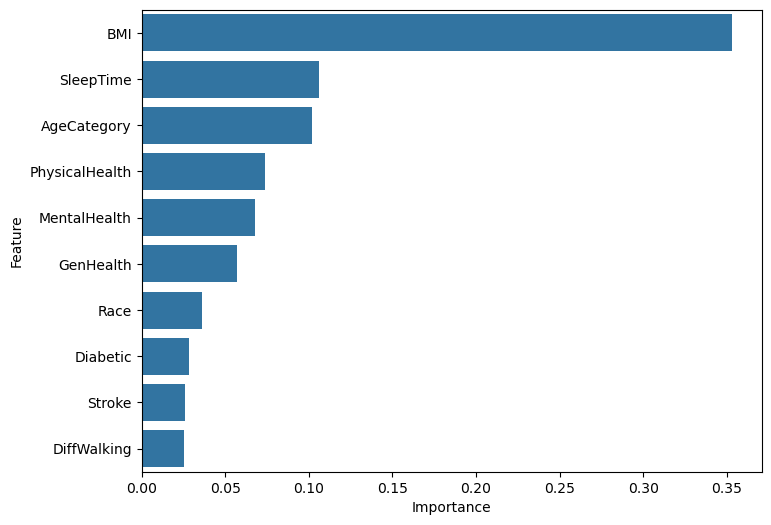

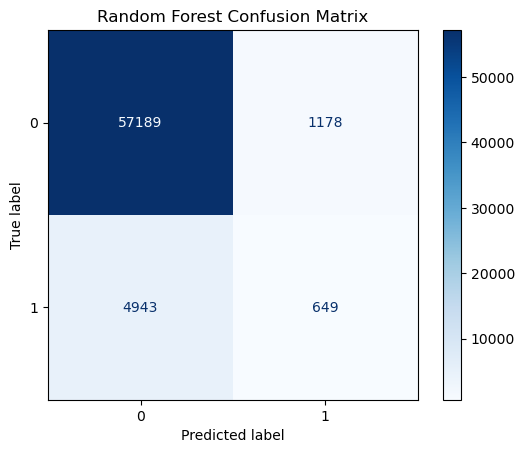

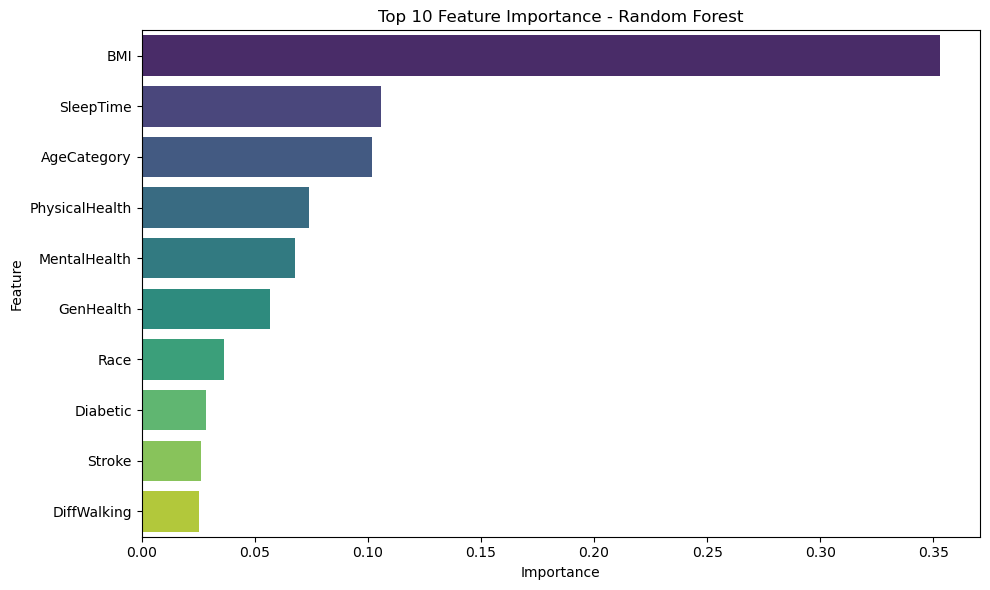

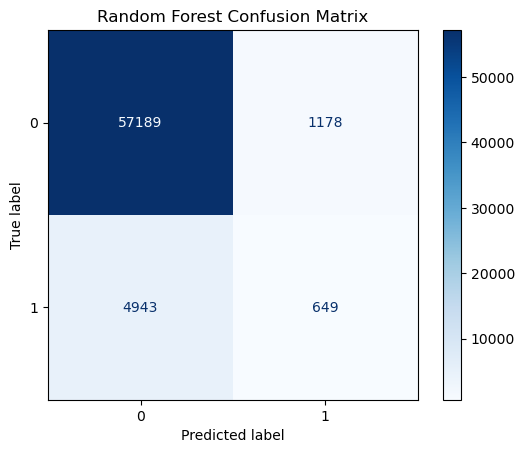

In [23]:
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay ,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("C:/Users/ThinkPad/Downloads/dataset/HeartDid/2020/heart_2020_cleaned.csv")

label_encoders = {}
for column in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# 3. Pisahkan fitur dan target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# 4. Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Training model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 6. Evaluasi
y_pred = model.predict(X_test)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_rf_pred = rf_model.predict(X_test)

# Evaluasi
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print("\nClassification Report:\n", classification_report(y_test, y_rf_pred))
%matplotlib inline
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_13424\3407719563.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis', legend=False)


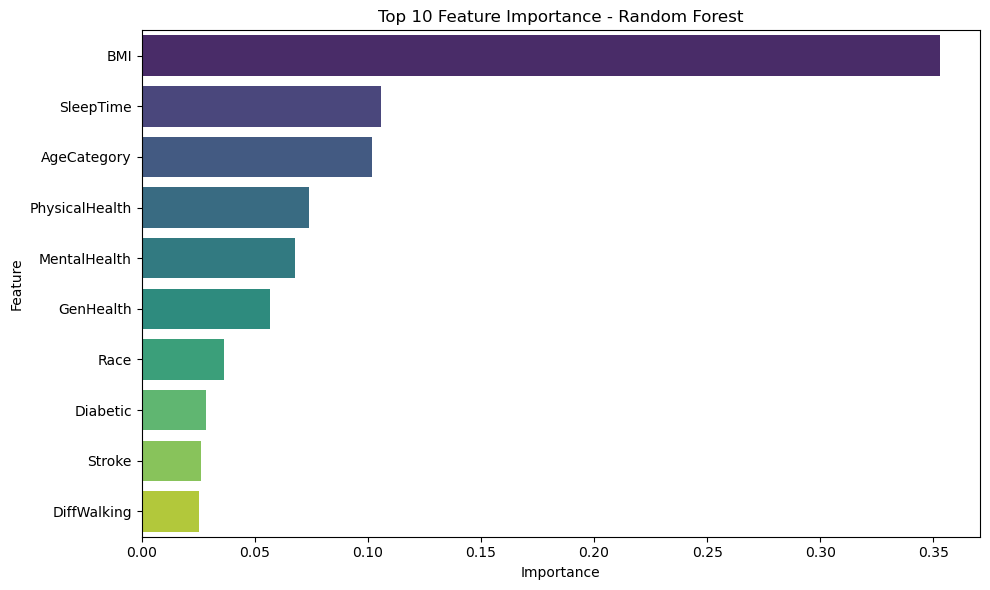

In [25]:
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis', legend=False)
plt.title("Top 10 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

In [27]:
pip install shap

   ---------------------------------------- 0.0/544.8 kB ? eta -:--:--
   ---------------------------------------- 544.8/544.8 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ----------------------- ---------------- 1.6/2.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------  2.6/2.7 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 5.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/28.1 MB 10.1 MB/s eta 0:00:03
   - -------------------------------------- 1.0/28.1 MB 10.1 MB/s eta 0:00:03
   --- ------------------------------------ 2.6/28.1 MB 4.2 MB/s eta 0:00:07
   ---- ----------------------------------- 3.1/28.1 MB 4.0 MB/s eta 0:00:07
   ----- ---------------------------------- 3.9/28.1 MB 3.7 MB/s eta 0:00:07
   ------ --------------------------------- 4.5/28.1 MB 3.6 MB/s eta 0:00:07
   ------ --------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
pip install ipywidgets
jupyter nbextension enable --py widgetsnbextension

In [3]:
pip install streamlit pandas scikit-learn seaborn matplotlib

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.9 MB 3.6 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.9 MB 3.4 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 3.4 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.9 MB 3.2 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.9 MB 3.3 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 3.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 3.2 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 3.3 MB/s eta 0:00:02
   --------------------------- ------------ 6.8/9.9 MB 3.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 3.1 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 3.1 MB/s eta 0:00:01
   ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
